# Tutorial: Convolutional Neural Networks (CNN)
> Created: Aug. 2024 for the FSU Course: *Machine Learning in Physics* <br>
> Updated: Sun Sep 20 2025: Adapted for Introduction to ML course at AIMS South Africa<br>
> Harrison B. Prosper<br>


## Introduction

In this tutorial, we try to classify galaxies according to their morphology using the Galaxy10 dataset from [AstroNN](https://astronn.readthedocs.io/en/latest/galaxy10.html), which contains 17,736 RGB (that is, 3-channel) $256\times256$-pixel galaxy images grouped into 10 morphology classes. Of these a subset of 12,600 images grouped into 7 morphology classes of 1,800 images each is used. To reduce the computational burden, each image is cropped to $96\times96$ pixels. Nevertheless, each 3-channel image is described by $96\times96\times 3 = 27,648$ bytes or 3,456 32-bit integers! The model of choice for classifying 2D images is the **convolutional neural network** (CNN), which is the subject of this notebook.

## Model

Here is a high-level view of the model we shall fit,
\begin{align}
\boldsymbol{y}(\boldsymbol{x}) & = \texttt{softmax}(\texttt{linear}(\texttt{flatten} (\texttt{g}_3(\texttt{g}_2(\text{g}_1(\texttt{g}_0(\boldsymbol{x} \,) \,) \, ) \, ) \, )\, )\,) .
\end{align}

The functions **softmax**, **flatten**, and **g** are defined as follows:

  * **softmax** For $K = 7$ output classes,
\begin{align*}
\text{softmax}(x)_k & = \frac{\exp(x_{k})}{\sum_{j=0}^{K-1} \exp(x_{j})} ,
\end{align*}
where $x_{k}$ denotes output $k$ of the linear function.  The
softmax function ensures that the $K$ outputs
sum to unity.

  * **flatten** Given tensor $\boldsymbol{x}$, this function unfolds the tensor into a 1D tensor.

  * **g** Given tensor $\boldsymbol{x}$, this function
  \begin{align}
  \text{g}(\boldsymbol{x}) = \texttt{maxpool}(\texttt{relu}(\texttt{conv2d}(\boldsymbol{x}))),
  \end{align}
convolves $\boldsymbol{x}$, applies the nonlinear function relu to every element of its tensor argument and finally performs a downsampling of the resulting image. The functions
 $\texttt{relu}$, $\texttt{maxpool}$, and $\texttt{conv2d}$ are defined below.

  * **relu** Given tensor $\boldsymbol{x}$, the function
\begin{align*}
\texttt{relu}(x) &= \texttt{max}(0, x)
\end{align*}
is applied
*element-wise*, that is, to every element of its argument.

  * **maxpool** Given tensor $\boldsymbol{x}$, this function uses a moveable window to downsample $\boldsymbol{x}$. In this tutorial, the moveable window  splits the tensor into non-overlapping pieces. For each piece, the maximum pixel value within that piece is returned. For example, if $\boldsymbol{x}$ is a 2D tensor, e.g., a matrix, of shape (96, 96), and the window is of shape (2, 2), maxpool splits the original matrix into $48 \times 48$ non-overlapping pieces of shape (2, 2) and returns the maximum value within each piece, thereby creating a new image of shape (48, 48).

  * **conv2d** Given tensor $\boldsymbol{x}$, this function returns a convolution of $\boldsymbol{x}$. The operation is described in detail below.

A high-level view, especially when represented pictorially, is a good way to understand the structure of a model.  But it is also good to try to understand the details...at least once! As is often true, a detailed mathematical description of a complicated function is made easier using a concrete example.

## Convolution
The input data into the first layer of our model are a batch of $N$ galaxy images $\boldsymbol{x}$ that form a 4-component tensor of shape $(N, C_\text{in}=3, H=96, W=96)$, where $C_\text{in}$ denotes the number of input channels and $H$ and $W$ are the height and width in pxiels of every channel. The output of the $\texttt{conv2d}$ function (implemented in the PyTorch class $\texttt{Conv2d}$) comprises $N$ images, each of $C_\text{out}$ channels. In this example, we have chosen to keep the height and width of the images unchanged. Each channel of an input image is convolved with each of $C_\text{out} \times C_\text{in}$  parameterized **filter**s of shape $(H_F, W_F) = (3, 3)$, indexed by $(n, m)$ where $0 \le n\le C_\text{out}-1$ and $0 \le m \le C_\text{in}-1$.  The collection of $C_\text{out} \times C_\text{in}$ filters, which also form a 4-component tensor,  is referred to as a **kernel**. The size of the first dimension of the kernel ($\mathbb{dim} = 0$) is the number of **output channels**, $C_\text{out} = 4$, the size of the second dimension is the number of **input channels**, $C_\text{in} = 3$ and the remaining two indices are the height and width of the filters that comprise the kernel. In addition to the $C_\text{out} \times C_\text{in} \times H_F \times W_F$ parameters of the kernel there are $C_\text{out}$ bias parameters, one for each output channel.

Unfortunately, the jargon is not consistent across the machine learning literature. What we call a filter is indeed often referred to as a filter, but it is also called a kernel, and what we call a kernel, that is, a stack of one or more filters, often has no specific name attached to it!

Consider a single filter $w_{n, m}$, indexed by  output and input channel indices $n$ and $m$, respectively, and of shape $(H_F, W_F) = (3, 3)$. Given an input channel $\boldsymbol{x}_m$, the output pixel $y_{n, m, i, j}$ with height and width indices $(i, j)$ is computed  as follows
\begin{align}
    y_{n, m, i,j} &= b_n + \sum_{r=-1}^1 \sum_{s=-1}^1  w_{n, m, r, s} \, x_{m, i+r,\,j+s} ,
\end{align}
where the bias $\boldsymbol{b}$ and weight $\boldsymbol{w}$ matrices are the parameters of the kernel and
where we have chosen to label the central matrix element of the filter with the indices $(0, 0)$ and the other elements of the filter with indices that can be positive or negative integers. The above convolution operation is followed by a pixel-by-pixel sum
\begin{align}
    y_{n, i, j} &= \sum_{m=0}^{C_\text{in}-1} y_{n, m, i, j},
\end{align}
over the $C_\text{in}$ input channels, thereby creating a $C_\text{out}$-channel output image.

However, for the above computations to work as shown, we need to surround each image with strips of pixels. This operation is called **padding**. Since our filter shape is $(3, 3)$, we need to pad every image with a single strip of pixels (with value zero). This padding makes it possible to center each of the filters (of shape $(3, 3)$) on every pixel, $(i, j)$, of the input channel. We are free to make other choices.
Since the input image is a $(96, 96)$ matrix padded with 1 strip of pixels around the boundary, and each of the filters is a $(3, 3)$ matrix,
the output of the convolution step will be a tensor of shape $(N, 4, 96, 96)$ provided that we use a **stride** of 1, that is, during the convolution we shift the filters a horizontal or vertical step of 1 pixel. Other choices are possible. By
construction, the output of the first convolutional layer will be $N$, 4-channel images of the same size as the original, namely $(96, 96)$.

### Down-sampling
A convolutional layer is often followed by a down-sampling, that is, coarse graining, layer that reduces the number of pixels per image. In this tutorial, the number of pixels in the image created by the convolutional layer is reduced by a factor 2 in both directions; that is, each of the 4 channels of the $(96, 96)$-pixel image is down-sampled to a $(48, 48)$-pixel channel by replacing the corresponding group of pixels of shape $(2, 2)$ with a pixel whose value is set to the largest value among the group of 4 pixels and using a stride of 2 horizontally and vertically so that the $2\times 2$ windows are nonoverlapping. This operation is called **max pooling**.
Again, other choices are possible.

After the down-sampling operation, the output tensor has shape $(N, 4, 48, 48)$. A relu nonlinearity is applied to each element of this tensor and completes one sequence of operations: convolution, down-sampling, and nonlinear activation.
This sequence is repeated until we reach the final layer. The input to the final layer is $N$, 7-channel, $6\times6$-pixel images. Each image is flattened to a 1D tensor  of size $7 \times 6 \times 6 = 252$, which is the input to a linear layer with 7 outputs. Finally, a softmax function is applied to normalize the sum of the outputs to one.

## Number of parameters
Our model consists of a sequence of 4 triplets ($\texttt{Conv2d}$, $\texttt{ReLU}$, $\texttt{MaxPool2d}$) of operations. The 4 $\texttt{Conv2d}$ operations have kernels with input and output channel counts $(3, 4), (4, 5), (5, 6)$, and $(6, 7)$, respectively. The same stride and padding is used for every $\texttt{Conv2d}$ operation and the same pooling operation, as described above, is used for every layer. The number of parameters per $\texttt{Conv2d}$ operation is given $C_\text{in} C_\text{out} H_F W_F + C_\text{out}$.
The number of parameters in a linear layer with $N_\text{in}$ inputs and $N_{out}$ outputs plus a bias parameter for each output is given by $N_\text{in} N_\text{out} + N_\text{out}$. From these expressions one can compute the total number of trainable parameters, that is, the dimensionality of the *empirical risk landscape* to be navigated.

## Discussion
The net effect of the sequence of nested layers, prior to flattening, is to transform each 3-channel, $(96, 96)$ input image into a 7-channel (6, 6) output image. The hope is that the output image captures the most relevant features of the input image thereby improving the accuracy of the subsequent classification. But why use convolution?

The intuition behind the convolution operation is that images tend to have similar features in different parts of the image. A filter that is sensitive to vertical features would tend to produce an output image that enhances vertical features, while suppressing the expression of horizontal features. It therefore seems plausible that if one could design filters that are sensitive to different image features, the set of filters could potentially transform an image into another in which the most relevant features are enhanced while the least relevant are suppressed.

In the early days of image recognition systems, researchers tried to describe in software what they considered to be the most relevant features in images. This proved to be extremely difficult and success was limited. Today hand coding is no longer necessary because the values of the parameters of the kernels can be determined automatically by minimizing an appropriate (average) loss function. However, the mere fact that a large number of images is needed to fit these parameters is evidence that current machine learning methods and models, while spectacularly successful, are still far removed from the internal models humans use to learn about the world.

A young child need be shown labeled objects, cat, dog, doll, truck, car, just a few times before being able to classify them correctly. The child can do this even when the objects are presented to her in orientations that differ from the ones used during the "training phase". This extraordinary ability suggests that the child's brain constructs a fault-tolerant model of each object using only its most relevant features and is able to match rapidly the input image with the stored, or more likely auto-reconstructed, fault-tolerant model. The model is clearly fault tolerant because the child is able to ignore "faults" such as viewing the objects in lighting that differs from that used during the "training phase", or ignoring the fact that now the car has lost a couple of wheels or the doll is now wearing different clothes.

Despite the truly impressive successes of machine learning, it is clear that machine learning-based artificial intelligence still has a long way to go. Of course, it could be that the age-old goal of building machines that think like humans is simply the wrong goal. After all, there are already many instances in which researchers have inadvertently succeeded in producing machines that mimic our prejudices, which is hardly progress. Therefore, perhaps we should embrace the "artificial" in artificial intelligence and the possibility that these machines will inevitably "think" differently from us. The trick, of course, is to have them "think" in a way that improves the human condition.

## Check if we're running on Google Colab

In [1]:
COLAB_FOLDER = 'MLP/04.CNN/code' # change as needed
GITHUB_USER  = 'hbprosper'
GITHUB_REPO  = 'mlinphysics'
GITHUB_FOLDERS = ['mlinphysics']
#------------------------------------------------------
try:
    from google.colab import drive
    drive.mount('/content/gdrive')
    print('\nGoogle Drive mounted\n')
    IN_COLAB = True
except:
    print('\nRunning locally\n')
    IN_COLAB = False

if IN_COLAB:
    MYDRIVE     = '/content/gdrive/MyDrive'
    GITHUB_BASE = 'https://raw.githubusercontent.com'
    MAIN        = 'refs/heads/main'
    GITHUB_PATH = f'{MYDRIVE}/{COLAB_FOLDER}'
    #------------------------------------------------------
    %cd {GITHUB_PATH}
    %rm -f {GITHUB_PATH}/clone2colab.ipynb
    !wget -q {GITHUB_BASE}/{GITHUB_USER}/{GITHUB_REPO}/{MAIN}/clone2colab.ipynb
    %run {GITHUB_PATH}/clone2colab.ipynb


Running locally



In [2]:
# standard system modules
import os, sys

# standard module for tabular data
import pandas as pd

# standard module for array manipulation
import numpy as np

# standard module for high-quality plots
import matplotlib as mp
import matplotlib.pyplot as plt

# standard research-level machine learning toolkit from Meta (FKA: FaceBook)
import torch
import torch.nn as nn
import torch.utils.data as dt

# module to access data in Hierarchical Data Format (HDF or H5 format)
import h5py

# module to plot pixelized images
import imageio.v3 as im

# module to reimport Python modules
import importlib

# module for saving/loading serialized Python objects
#import joblib

# module for shell utilities
import shutil

# ML in physics module
import mlinphysics.nn as mlp
import mlinphysics.utils.data as dat
import mlinphysics.utils.monitor as mon

if not IN_COLAB:
    plt.rcParams.update({
      "text.usetex": shutil.which('latex') is not None,
      "font.family": "sans-serif",
      "font.sans-serif": "Helvetica",
      "font.size": 14
  })

CHECK = "\u2705"
FAIL  = "\u274C"
WARN  = "\u26A0"

## Set Computational Device

In [3]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'\n\tAvailable device: {str(DEVICE):4s}\n')


	Available device: cpu 



# PART 1

## Convolution Exercise
Let $y = f * g$ be the convolution of the functions $f(x)$ and $g(x)$. By definition,

$y(t)  = \int f(\tau) \, g(t-\tau) \, d\tau .$

In the exercise below, we compute the convolution of a 1-channel image using $\texttt{Conv2d}$ and using an explicit calculation.

### Create a 1-channel $5 \times 5$-pixel image

image.shape: (1, 5, 5)


array([[0.4, 0.3, 0.8, 0.3, 0.4],
       [0.3, 0.2, 0.9, 0.2, 0.3],
       [0.7, 0.9, 1. , 0.9, 0.7],
       [0.3, 0.2, 0.9, 0.2, 0.3],
       [0.4, 0.3, 0.5, 0.3, 0.4]])

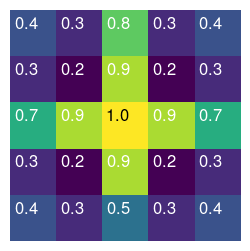

In [4]:
image = np.array([[0.4,0.3,0.8,0.3,0.4],
                  [0.3,0.2,0.9,0.2,0.3],
                  [0.7,0.9,1.0,0.9,0.7],
                  [0.3,0.2,0.9,0.2,0.3],
                  [0.4,0.3,0.5,0.3,0.4]]).reshape(1,5,5)

print('image.shape:', image.shape)

def plot_image(image, fgsize=(3, 3), filename='image.png'):

    image = image.transpose(1, 2, 0) # (C, H, W) => (H, W, C)
    H, W, C = image.shape

    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=fgsize)

    ax.set_xticks(np.arange(0, W, 1))
    ax.set_yticks(np.arange(0, H, 1))
    ax.imshow(image, extent=(0, W, H, 0))
    ax.grid()

    ii = H // 2
    dx = 0.1
    dy = 0.4
    for i in range(H):
        for j in range(W):
            z = image[i, j, 0]
            x = j + dx
            y = i + dy
            if i == ii and j == ii:
                c = 'black'
            else:
                c = 'white'
            ax.text(x, y, f'{z:3.1f}', color=c, fontsize=12)
    ax.axis('off')
    #fig.tight_layout()
    plt.savefig(filename)

figsize = np.array([3, 3])
plot_image(image, fgsize=figsize, filename='input_image.png')

image[0,:,:]

### Compute convolution using `Conv2d`
  * $C_{in} = 1$ input channel, $C_{out} = 3$ output channels
  * kernel with filters of shape $(3, 3)$
  * stride of 1 pixel
  * padding of 1 pixel

Conv2d parameters
  weight.shape: (3, 1, 3, 3)
  bias.shape  : (3,)

input_image.shape : torch.Size([1, 1, 5, 5])
output_image.shape: torch.Size([3, 5, 5])



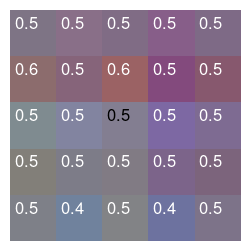

In [5]:
C_in  = 1
C_out = 3
H_F   = 3
W_F   = 3
STRIDE= 1
PAD   = 1

conv2d = nn.Conv2d(in_channels=C_in,
                   out_channels=C_out,
                   kernel_size=(H_F, W_F),
                   stride=STRIDE,
                   padding=PAD)

# get weights (after detaching from computation tree)
weight = conv2d.state_dict()['weight'].detach().numpy()
print('Conv2d parameters')
print('  weight.shape:', weight.shape)

# get biases
bias = conv2d.state_dict()['bias'].detach().numpy()
print('  bias.shape  :', bias.shape)
print()

# convert image to a floating point tensor of shape  (N, C_in, H, W)
C_in, H, W  = image.shape
input_image = torch.Tensor(image).view(1, C_in, H, W)
print('input_image.shape :', input_image.shape)

# convolve image and squeeze away dim=0
output_image = conv2d(input_image).squeeze() # shape (C_out, H, W)
print('output_image.shape:', output_image.shape)
print()

# map pixel values of convolved image to [0, 1] and dislay image
sigmoid = nn.Sigmoid()
display_image = sigmoid(output_image).detach().numpy()
plot_image(display_image, filename='convolved_image.png')

### Pad image with a single row of pixels
Input shape must be (C, H, W)

padded image: (1, 7, 7)


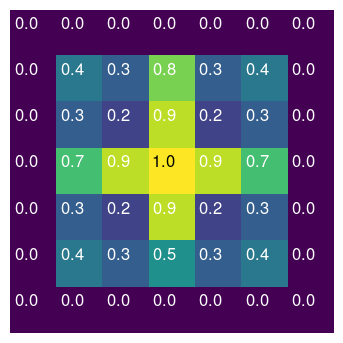

In [6]:
def pad_image(image):
    C, H, W = image.shape

    # pad vertically
    padding = np.zeros(H).reshape(1, H, 1)
    image   = np.concatenate((padding, image, padding), axis=2)

    # pad horizontally
    padding = np.zeros(W+2).reshape(1, 1, W+2)
    image   = np.concatenate((padding, image, padding), axis=1)

    return image

padded_image = pad_image(image)
print('padded image:', padded_image.shape)

# plot padded image
C, H, W = image.shape
figsize2 = figsize * (H+2)/H
plot_image(padded_image, fgsize=figsize2, filename='padded_image.png')

In [7]:
def MyConv2d(image, c_out, W, B, padding=1):
    '''
    image:         image of shape (channels, height, width)
    c_out:         number of output channels
    W, B:          weights and biases from Conv2d
    padding:       width of padding in pixels [1]
    '''

    c_in, height, width = image.shape

    p_image = pad_image(image)

    # assume filter/kernel size is an odd number
    # determined from the padding parameter
    kernel_size = 2 * padding + 1

    # we'll convolve the padded image, but we need to know the
    # indices of the original image within the padded image
    pixel_indices  = np.arange(0, height+2*padding, 1)[padding:-padding]

    # construct filter indices so that (0, 0) is the center of the filter
    filter_indices = np.arange(0, kernel_size, 1) - kernel_size // 2

    # this will be the output image with c_out channels
    o_image = np.zeros(c_out*height*width).reshape(c_out, height, width)

    # loop over input channels
    for m in range(c_in):

        Y = []

        # loop over output channels
        for n in range(c_out):

            # bias (one number per output channel)
            b = B[n]

            # create bias matrix
            Y.append(np.array([[b]*width]*height))

            # loop over pixels (i, j) of output image
            for i in pixel_indices:

                for j in pixel_indices:

                    # convolve padded image
                    for r in filter_indices:
                        for s in filter_indices:
                            Y[n][i-1, j-1] += W[n, m, r+1, s+1] * p_image[m, i+r, j+s]
        o_image += np.array(Y)

    return o_image

print('Conv2d')
print(output_image.detach().numpy())
print()

Y = MyConv2d(image, C_out, weight, bias)
print('MyConv2d')
print(Y)

Conv2d
[[[-0.01514199  0.15628465  0.01837231  0.12845781 -0.01894724]
  [ 0.20318562  0.1052191   0.43890268  0.06710877  0.12032217]
  [-0.00543213  0.05306618  0.05951564 -0.03403154 -0.00820697]
  [ 0.04632242 -0.02713432  0.02419616 -0.04226131 -0.05157402]
  [-0.01744071 -0.23565927  0.05355281 -0.28836575 -0.02625695]]

 [[-0.16588718 -0.25654063 -0.30051377 -0.5305283  -0.331256  ]
  [-0.29821932 -0.4263583  -0.46588826 -0.87620777 -0.6328764 ]
  [ 0.18288445  0.07558042 -0.00955415 -0.35672447 -0.3166072 ]
  [ 0.00436807 -0.04513399 -0.05655012 -0.42909575 -0.4367373 ]
  [ 0.01787177  0.04165095  0.06556526 -0.2055138  -0.18297985]]

 [[ 0.09487031  0.14582662  0.08914687  0.15580475  0.10229801]
  [-0.28854463 -0.07073745 -0.43801123 -0.03288124 -0.26615405]
  [ 0.2675063   0.5300714   0.28735936  0.5721233   0.3012116 ]
  [-0.0999068   0.14708817  0.07073496  0.1791439  -0.04311558]
  [ 0.14400487  0.479935    0.11591113  0.5169307   0.16289945]]]

MyConv2d
[[[-0.01514199  0

# PART 2 - TRAINING

## Load Galaxy Images
Load galaxy images and normalize pixels by dividing each by 256.

In [12]:
importlib.reload(dat)

datafile = '../data/galaxy10.h5'

dat.download(datafile)

def load_images(filename='../data/galaxy10.h5'):
    with h5py.File(filename, 'r') as F:
        images = np.array(F['images']) / 256 # normalize pixels
        labels = np.array(F['labels'])       # class labels, k = 0 to 6
    return images, labels

def plot_images(images, targets,
                n_rows=4,
                n_cols=5):

    f_size = (6, n_rows * 1.3)

    fig, axs = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=f_size)

    # note use of flatten() to convert the matrix
    # of shape (nrows, ncols) to a 1-d array.
    axs = axs.flatten()
    n = len(axs)

    # use "zip" to create an list of shape (N, 3)
    for image, target, ax in zip(images[:n], targets[:n], axs):

        ax.axis('off')

        ax.imshow(image)

        # Note: (x, y) coordinates are in pixels,
        # where (0, 0) is the upper left corner
        ax.text(8, 16, f'{target:d}', color='white')

    plt.savefig('galaxy_images.png')

number of images: 12600


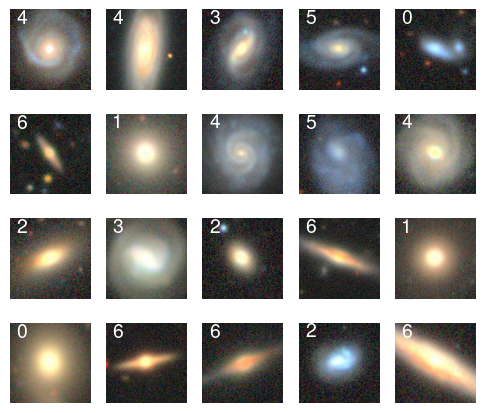

In [13]:
images, targets = load_images()

print(f'number of images: {len(images):d}')

plot_images(images, targets)

## Configuration

In [10]:
# name of model
# -----------------------------------------
name = 'galaxy'

# choose whether to create or load a configuration file
load_existing_config = False

if load_existing_config:
    config = mlp.Config(f'{name}.yaml')
else:
    # create new configuration
    config = mlp.Config(name, dirname='CNN')

    # training configuration
    # -----------------------------------------
    n_images   = len(images)
    batch_size = 32
    n_iters_per_epoch = 316                      # number of iterations/epoch
    train_size = n_iters_per_epoch * batch_size
    test_size  = 1_500
    val_size   = n_images - train_size - test_size

    config('batch_size', batch_size)
    config('train_size', train_size)           # set training sample size
    config('test_size',  test_size)            # set test sample size
    config('val_size',   val_size)             # set validation sample size

    config('monitor_step',   50)  # set monitor training every n (=10) iterations
    config('delete', True)        # delete losses file before training, if True
    config('frac', 0.015)         # save model if average loss decreases by more
                                  # than frac percent

    # optimizer / scheduler configuration
    # -----------------------------------------
    # a step comprises a given number of iterations
    config('n_epochs', 400)       # number of training epochs
    config('n_iters_per_epoch', n_iters_per_epoch)
    config('n_iterations', config('n_epochs') * config('n_iters_per_epoch'))

    config('n_steps', 4)          # number of training steps
    config('n_iters_per_step', config('n_iterations') // config('n_steps'))

    config('base_lr', 1.e-3)      # initial learning rate
    config('gamma', 0.8)          # learning rate scale factor

    print(f'\nSave configuration to file {config.cfg_filename}\n')
    config.save()

print(config)


Save configuration to file runs/2025-10-29_1910/galaxy_config.yaml

name: galaxy
file:
  losses: runs/2025-10-29_1910/galaxy_losses.csv
  params: runs/2025-10-29_1910/galaxy_params.pth
  init_params: runs/2025-10-29_1910/galaxy_init_params.pth
  plots: runs/2025-10-29_1910/galaxy_plots.png
batch_size: 32
train_size: 10112
test_size: 1500
val_size: 988
monitor_step: 50
delete: true
frac: 0.015
n_epochs: 400
n_iters_per_epoch: 316
n_iterations: 126400
n_steps: 4
n_iters_per_step: 31600
base_lr: 0.001
gamma: 0.8



## Prepare Datasets and DataLoaders
  1. Split data into training, testing, and validation sets.
  2. Change shape of tensors to from $(N, H, W, C)$ to $(N, C, H, W)$.
  3. Move them to computational device.

In [11]:
print(images.shape)

t_images = images.transpose(0, 3, 1, 2)

print(t_images.shape)

(12600, 96, 96, 3)
(12600, 3, 96, 96)


### Datasets

In [12]:
importlib.reload(dat)

train_size = config('train_size')
val_size   = config('val_size')
test_size  = config('test_size')

# training dataset (this defines the empirical risk to be minimized)
print('training data')
train_data = dat.Dataset(t_images,
                         start=0,
                         end=train_size,
                         targets=targets)

# a random subset of the training data to check for overtraining
# by comparing with the empirical risk from the validation set
print('training data for validation')
train_data_val = dat.Dataset(t_images,
                             start=0,
                             end=train_size,
                             targets=targets,
                             random_sample_size=val_size)


# validation dataset (for monitoring training)
print('validation data')
val_data = dat.Dataset(t_images,
                       start=train_size,
                       end=train_size + val_size,
                       targets=targets)

# test dataset
print('test data')
test_data= dat.Dataset(t_images,
                       start=train_size + val_size,
                       end=train_size + val_size + test_size,
                       targets=targets)

training data
Dataset
  shape of x: torch.Size([10112, 3, 96, 96])
  shape of y: torch.Size([10112])

training data for validation
Dataset
  shape of x: torch.Size([988, 3, 96, 96])
  shape of y: torch.Size([988])

validation data
Dataset
  shape of x: torch.Size([988, 3, 96, 96])
  shape of y: torch.Size([988])

test data
Dataset
  shape of x: torch.Size([1500, 3, 96, 96])
  shape of y: torch.Size([1500])



### DataLoaders

In [13]:
print('train data loader')
train_loader = dt.DataLoader(train_data,
                             batch_size=config('batch_size'),
                             shuffle=True)

print('train data loader for validation')
train_loader_val = dt.DataLoader(train_data_val,
                                 batch_size=len(train_data_val))

print('validation data loader')
val_loader  = dt.DataLoader(val_data,
                            batch_size=len(val_data))

print('test data loader')
test_loader = dt.DataLoader(test_data,
                            batch_size=len(test_data))

train data loader
train data loader for validation
validation data loader
test data loader


In [14]:
importlib.reload(dat)
train_loader2 = dat.DataLoader(train_data,
                             batch_size=config('batch_size'),
                             shuffle=True)

DataLoader
  maxiter:             316
  batch_size:           32
  shuffle_step:        316



In [15]:
%%timeit -r 5 -n 10 
for i, (x, y) in enumerate(train_loader):
    pass

180 ms ± 14.9 ms per loop (mean ± std. dev. of 5 runs, 10 loops each)


In [16]:
%%timeit -r 5 -n 10
for i, (x, y) in enumerate(train_loader2):
    pass

86 ms ± 2.16 ms per loop (mean ± std. dev. of 5 runs, 10 loops each)


## Build model

In [17]:
class ConvBlock(nn.Module):

    def __init__(self, in_channels, out_channels, padding=1, dropout=0.2):

        super().__init__()

        kernel_size = 2*padding + 1

        self.conv1 = nn.Conv2d(in_channels=in_channels,
                               out_channels=out_channels,
                               kernel_size=kernel_size,
                               stride=1,
                               padding=padding)
        self.relu    = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.maxpool = nn.MaxPool2d(kernel_size=(2, 2), stride=2)

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.maxpool(x)
        return x

class GalaxyClassifier(mlp.Model):

    def __init__(self, image_size=96, channels=[3, 4, 5, 6, 7], padding=1):
        super().__init__()

        # number of convolutional layers
        nlayers = len(channels)-1

        # number of inputs into classification layer
        final_image_size = int(image_size /  2**nlayers)
        ninputs = channels[-1] * final_image_size**2

        layers  = [ConvBlock(channels[i], channels[i+1], padding) for i in range(nlayers)]

        layers.append(nn.Flatten())
        layers.append(nn.Linear(ninputs, 7))
        layers.append(nn.Softmax(dim=1))

        self.layers = nn.ModuleList(layers)

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

## Instantiate model

In [18]:
importlib.reload(mlp)

model = GalaxyClassifier().to(DEVICE)
print(model)
print()

print('number of parameters:', mlp.number_of_parameters(model))
print()

GalaxyClassifier(
  (layers): ModuleList(
    (0): ConvBlock(
      (conv1): Conv2d(3, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (relu): ReLU()
      (dropout): Dropout(p=0.2, inplace=False)
      (maxpool): MaxPool2d(kernel_size=(2, 2), stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): ConvBlock(
      (conv1): Conv2d(4, 5, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (relu): ReLU()
      (dropout): Dropout(p=0.2, inplace=False)
      (maxpool): MaxPool2d(kernel_size=(2, 2), stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (2): ConvBlock(
      (conv1): Conv2d(5, 6, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (relu): ReLU()
      (dropout): Dropout(p=0.2, inplace=False)
      (maxpool): MaxPool2d(kernel_size=(2, 2), stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (3): ConvBlock(
      (conv1): Conv2d(6, 7, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (relu): ReLU()
      (dropout): Dropout(p=0

## Count Parameters by Layer

In [19]:
# get parameter names (#.weight, #.bias)
keys = list(model.state_dict().keys())

n_params = 0

# loop over parameters in steps of 2
for i in range(0,len(keys),2):

    W = model.state_dict()[keys[i]]     # weights
    B = model.state_dict()[keys[i+1]]   # biases

    # calculate number of parameters / Conv2d
    try:
        C_out, C_in, H_F, W_F = W.shape
        n = C_in * C_out * H_F * W_F + C_out
    except:
        C_out, C_in = W.shape
        n = C_in * C_out + C_out

    n_params += n

    print(f'{C_in:5d}, {C_out:5d}, {n:5d}')

print(f'{' ':5s}  {'total':5s}  {n_params:5d}')
print()
print('number of parameters:', mlp.number_of_parameters(model))

    3,     4,   112
    4,     5,   185
    5,     6,   276
    6,     7,   385
  252,     7,  1771
       total   2729

number of parameters: 2729


## Write Our Own `AverageCrossEntropyLoss`

**Notes**

The function object `AverageCrossEntropyLoss` is called as follows:
```python
    empirical_risk = AverageCrossEntropyLoss()
        :              :
    R = empirical_risk(outputs, targets)
```
where
 1. `outputs` is a 2D tensor of shape $(\texttt{batch-size}, K)$ and is the output of the classifier.
 2. `targets` is a 1D tensor of shape $(\texttt{batch-size},)$ and contains the true class index $(k = 0,\cdots,K-1), K = 7$ of every image.

The **cross entropy** is defined by

$
\begin{align}
\quad H(p, f) &= -\sum_k p_k \log f_k ,
\end{align}
$

the **entropy** is defined by

$
\begin{align}
\quad H(p) = -\sum_i p_i \log p_i,
\end{align}
$

and the **Kullback-Leibler divergence** by

$
\begin{align}
D(p\,\lvert\rvert\,f) &= \sum_i p_i \log(p_i/f_i), \nonumber\\
           &= -\sum_i p_i \log f_i - \left[-\sum_i p_i \log p_i \right],\nonumber\\
           &= H(p, f) - H(p) .
\end{align}
$

The cross entropy is minimized when the estimated
probabilities $f_i$ match the true probabilities $p_i$, that is, when the
 cross entropy equals the entropy.

**Hints**:  

  1. For every image $x_i$ the cross entropy loss is $L_i = -\log f_{k_i}$, where $k_i \in [0,\cdots, K-1]$.
  2. Therefore, for every image in the batch of images, pick the classifier
        output corresponding to its class index, $k_i$.
  3. This can be done in two lines of code!


In [20]:
class AverageCrossEntropyLoss():

    def __init__(self):
        pass

    def __call__(self, outputs, targets):
        """
        outputs:  shape (batch_size, number_classes), pre-softmax outputs
        targets:  shape (batch_size, ), class indices [0,...,K-1]
        """

        # Elements of a tensor can be accessed using the syntax
        #  t = outputs[range-object, 1D-tensor]

        # Note: outputs is a (-1, 7) tensor. For each image pick the
        # output corresponding to its true class. Recall that targets
        # is a 1D tensor  of class labels.
        # For every row, pick the value in the column corresponding
        # to the image's class label.
        outputs = outputs[range(len(targets)), targets]

        return -torch.mean(torch.log(outputs))

## Instantiate Training Objects
  1. `optimizer`
  1. `scheduler`
  1. `objective`

In [21]:
optimizer = torch.optim.Adam(model.parameters(), lr=config('base_lr'))

scheduler = mlp.get_steplr_scheduler(optimizer, config)

objective = mlp.Objective(model, AverageCrossEntropyLoss())

number of milestones:          3

Step | Milestone | LR
-----------------------------
   0 |         0 | 1.0e-03   
-----------------------------
   1 |     31600 | 8.0e-04   
   2 |     63200 | 6.4e-04   
   3 |     94800 | 5.1e-04   

number of iterations:         126400



In [22]:
def accuracy(outputs, targets):
    # For each image, return its predicted class label using argmax.
    #
    # argmax scans the numpy along the specified axis, here the
    # horizontal axis, which is in the class direction, and returns the
    # ordinal value of the maximum value, which is the predicted class.
    # Note: outputs must be converted from a tensor to a numpy array
    # before being passed to argmax. axis=1 is to numpy what dim=1 is
    # to PyTorch.
    outputs = np.argmax(outputs.data.cpu().numpy(), axis=1)

    # count how often the predicted class matches the actual class and
    # compute the fraction of correct predictions.
    # Note: targets must be converted to a numpy array for the
    # comparison to work since outputs is a numpy array.
    return float(np.mean(outputs==targets.data.cpu().numpy()))

## Define Trainer

In [23]:
def train(objective, optimizer, scheduler,
          train_loader, train_small_loader, val_loader,
          config):

    # get configuration info
    lossfile   = config('file/losses')
    paramsfile = config('file/params')
    step       = config('monitor_step')
    delete     = config('delete')
    frac       = config('frac')
    nepochs    = config('n_epochs')
    niters     = config('n_iterations')

    # instantiate object that saves average losses to
    # a csv file for realtime monitoring

    losswriter = mon.LossWriter(niters,
                                lossfile,
                                step=step,
                                delete=delete,
                                frac=frac,
                                model=objective.model,
                                paramsfile=paramsfile)

    # instantiate learning rate step scheduler
    lrscheduler = mlp.LRStepScheduler(optimizer, scheduler)

    # -----------------------------
    # training loop
    # -----------------------------
    ii = -1
    for epoch in range(nepochs):

        for x, y in train_loader:

            ii += 1

            # set mode to training so that training-specific
            # operations such as dropout, etc., are enabled.
            objective.train()

            # clear all gradients
            optimizer.zero_grad()

            # compute empirical risk
            R = objective(x, y)

            # compute gradients
            R.backward()

            # take one step downhill in the empirical risk landscape
            optimizer.step()

            # check whether to update learning rate
            lrscheduler.step()

            # I'm alive printout
            if (ii % step == 0) or (ii == niters-1):

                # compute average losses on training and validation data
                t_loss = mlp.compute_avg_loss(objective, train_small_loader)
                v_loss = mlp.compute_avg_loss(objective, val_loader)

                # return current learning rate
                lr = lrscheduler.lr()

                # update loss file
                losswriter(ii, t_loss, v_loss, lr, epoch)

In [24]:
importlib.reload(mlp)
importlib.reload(mon)

TRAIN = False

if TRAIN:
    train(objective, optimizer, scheduler,
          train_loader, train_loader_val, val_loader,
          config)
    
    monitor = mon.Monitor(config('file/losses'))
    monitor.plot()

## Compute Accuracy On Test Set

In [25]:
model.load(config('file/params'))

test_x, test_y = next(iter(test_loader))

y_pred = model(test_x)

acc = accuracy(y_pred, test_y)

print('\nPercentage of correct predictions: %8.1f%s' % (100*acc, '%'))


Percentage of correct predictions:     68.7%


## Plot Confusion Matrix

In [26]:
def plot_confusion_matrix(y_pred, y,
                          t=0.5,
                          gfile='confusion_matrix.png'):

    from sklearn.metrics import confusion_matrix

    # Calculate the confusion matrix
    conf_matrix = confusion_matrix(y_true=y, y_pred=y_pred)

    # Print the confusion matrix using Matplotlib
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.matshow(conf_matrix, cmap=plt.cm.rainbow, alpha=0.8)

    for i in range(conf_matrix.shape[0]):
        for j in range(conf_matrix.shape[1]):
            ax.text(x=j, y=i, s=conf_matrix[i, j],
                    va='center', ha='center', size='x-large')

    plt.xlabel('Predicted Labels', fontsize=16)
    plt.ylabel('True Labels', fontsize=16)
    plt.title(f'Confusion Matrix', fontsize=16)
    fig.tight_layout()

    plt.savefig(gfile)
    plt.show()

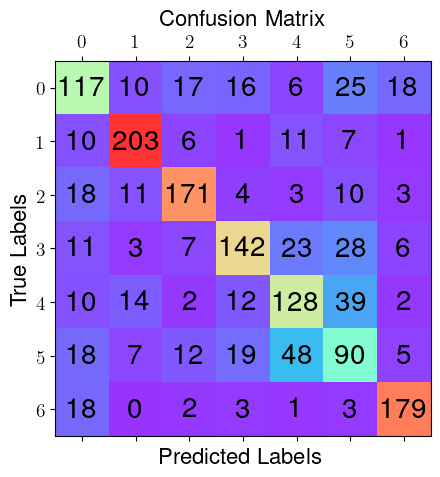

In [27]:
y_hat  = np.argmax(y_pred.data.cpu().numpy(), axis=1)

y_true = test_y.data.cpu().numpy()

plot_confusion_matrix(y_hat, y_true)